---
---

# Classification of CTG Findings
---
---

I am a data scientist and would like to convince a hospital to develop a system for the automatic pre-classification of CTG findings. This would help alleviate the workload on doctors and enable early intervention in cases of abnormalities. It would also save time and reduce costs.

# Imports and Settings

In [99]:
import copy
import os
import random
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
pd.options.display.max_columns = None

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from torchsummary import summary
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from ucimlrepo import fetch_ucirepo

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.set_num_threads(1)

EPOCHS        = 200
BATCH_SIZE    = 32
INPUT_SIZE    = 21
NUM_CLASSES   = 3
LEARNING_RATES = [0.001, 0.01]

# Task 1 -- The Data

* The Link for the Data set: https://archive.ics.uci.edu/dataset/193/cardiotocography
* The License is: CC BY 4.0
* The authors are D. Campos and J. Bernardes


The dataset contains 2,126 fetal cardiotocograms (CTGs) in which heart rate and uterine contraction characteristics were automatically measured. Three expert obstetricians classified each recording. The dataset is suitable for 3-class classification (Normal, Suspect, or Pathological) or 10-class classification based on morphological patterns.
I would like to use the 3-class classification as the target. This will allow pathological cases to be detected earlier. 

## The Raw Data


In [100]:
# fetch dataset 
cardiotocography = fetch_ucirepo(id=193) 
  
# data (as pandas dataframes) 
X = cardiotocography.data.features 
y = cardiotocography.data.targets 
  
raw_data = X.copy()
raw_data["NSP"] = y["NSP"].values #so that the 3 classes are used as target

# metadata 
print(cardiotocography.metadata) 
  
# variable information 
print(cardiotocography.variables) 


{'uci_id': 193, 'name': 'Cardiotocography', 'repository_url': 'https://archive.ics.uci.edu/dataset/193/cardiotocography', 'data_url': 'https://archive.ics.uci.edu/static/public/193/data.csv', 'abstract': 'The dataset consists of measurements of fetal heart rate (FHR) and uterine contraction (UC) features on cardiotocograms classified by expert obstetricians.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 2126, 'num_features': 21, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['CLASS', 'NSP'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2000, 'last_updated': 'Fri Mar 15 2024', 'dataset_doi': '10.24432/C51S4N', 'creators': ['D. Campos', 'J. Bernardes'], 'intro_paper': None, 'additional_info': {'summary': '2126 fetal cardiotocograms (CTGs) were automatically processed and the respective diagnostic features measured. The CTGs were also classified

In [101]:
print(raw_data.shape)
raw_data.head()

(2126, 22)


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
0,120,0.000,0.0,0.000,0.000,0.0,0.0,73,0.5,43,2.4,64,62,126,2,0,120,137,121,73,1,2
1,132,0.006,0.0,0.006,0.003,0.0,0.0,17,2.1,0,10.4,130,68,198,6,1,141,136,140,12,0,1
2,133,0.003,0.0,0.008,0.003,0.0,0.0,16,2.1,0,13.4,130,68,198,5,1,141,135,138,13,0,1
3,134,0.003,0.0,0.008,0.003,0.0,0.0,16,2.4,0,23.0,117,53,170,11,0,137,134,137,13,1,1
4,132,0.007,0.0,0.008,0.000,0.0,0.0,16,2.4,0,19.9,117,53,170,9,0,137,136,138,11,1,1


The dataset still looks quite confusing here because of the abbreviations. In later tasks i will add the description names.

| Feature | Group | Range | Explanation |
|---------|-------|-------|-------------|
| LB | Fetal Heart Rate | 106 to 160, integer | FHR baseline in beats per minute; resting heart rate of the fetus |
| AC | Fetal Heart Rate | 0.000 to 0.019, float | Number of accelerations per second |
| FM | Fetal Heart Rate | 0.000 to 0.481, float | Number of fetal movements per second |
| UC | Uterine Contractions | 0.000 to 0.015, float | Number of uterine contractions per second |
| DL | Fetal Heart Rate | 0.000 to 0.015, float | Number of light decelerations per second |
| DS | Fetal Heart Rate | 0.000 to 0.001, float | Number of severe decelerations per second |
| DP | Fetal Heart Rate | 0.000 to 0.005, float | Number of prolongued decelerations per second |
| ASTV | Fetal Heart Rate | 0 to 100, integer | Percentage of time with abnormal short term variability |
| MSTV | Fetal Heart Rate | 0.2 to 7.0, float | Mean value of short term variability |
| ALTV | Fetal Heart Rate | 0 to 100, integer | Percentage of time with abnormal long term variability |
| MLTV | Fetal Heart Rate | 0.0 to 50.7, float | Mean value of long term variability |
| Width | FHR Histogram | 0 to 180, integer | Width of the FHR histogram (Max minus Min) |
| Min | FHR Histogram | 50 to 159, integer | Minimum value of the FHR histogram |
| Max | FHR Histogram | 122 to 238, integer | Maximum value of the FHR histogram |
| Nmax | FHR Histogram | 0 to 18, integer | Number of histogram peaks |
| Nzeros | FHR Histogram | 0 to 10, integer | Number of histogram zeros |
| Mode | FHR Histogram | 60 to 187, integer | Histogram mode |
| Mean | FHR Histogram | 73 to 182, integer | Histogram mean |
| Median | FHR Histogram | 77 to 186, integer | Histogram median |
| Variance | FHR Histogram | 0 to 269, integer | Histogram variance |
| Tendency | FHR Histogram | -1, 0, or 1, integer | Histogram tendency: -1 = left asymmetric, 0 = symmetric, 1 = right asymmetric |
| NSP | Target | 1, 2, or 3, integer | Target variable: 1 = Normal, 2 = Suspect, 3 = Pathologic |

The dataset is usefull for the pitched task, because it has real clinical data, so they reflect the actual conditions. With 21 variables it gives enough input to learn patterns. 

# Task 2 -- Initial Data Analysis

In [102]:
raw_data.shape

(2126, 22)

The data has 2126 cases and 21 features and one target variable. 

In [103]:
raw_data.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,8.187629,70.445908,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,5.628247,38.955693,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,0.000000,3.000000,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,4.600000,37.000000,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,7.400000,67.500000,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,10.800000,100.000000,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,50.700000,180.000000,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


There are notable differences in the scales across the features: LB ranges from 106 to 160, while FM reaches values from 0.000 to 0.481. This means that feature normalization will be necessary. 

In [104]:
raw_data.dtypes

LB            int64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV          int64
MSTV        float64
ALTV          int64
MLTV        float64
Width         int64
Min           int64
Max           int64
Nmax          int64
Nzeros        int64
Mode          int64
Mean          int64
Median        int64
Variance      int64
Tendency      int64
NSP           int64
dtype: object

All features are numeric. Most FHR signal features are stored as floats, histogram features as integers.

In [105]:
raw_data.isna().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Min         0
Max         0
Nmax        0
Nzeros      0
Mode        0
Mean        0
Median      0
Variance    0
Tendency    0
NSP         0
dtype: int64

The data has no missing features.

In [106]:
raw_data.duplicated().sum()

np.int64(13)

The dataset seems to contain 13 duplicate rows. These will be removed in the preprocessing step.

In [107]:
raw_data["NSP"].value_counts().sort_index()

NSP
1    1655
2     295
3     176
Name: count, dtype: int64

In [108]:
class_counts = raw_data["NSP"].value_counts().sort_index()
class_labels = {1: "Normal", 2: "Suspect", 3: "Pathologic"}
class_dist = class_counts.rename(index=class_labels)
class_dist_pct = (class_dist / len(raw_data) * 100).round(2)

dist_df = pd.DataFrame({
    "Count": class_dist,
    "Percentage (%)": class_dist_pct
})

In [109]:
dist_df

,Count,Percentage (%)
NSP,,
Normal,1655,77.85
Suspect,295,13.88
Pathologic,176,8.28


There is a class imbalance. Nearly 78% of the target are normal cases. Around 14% are suspicous and 8& are pathologic. 

# Task 3 -- Preprocessing



In [110]:
raw_data = raw_data.drop_duplicates().reset_index(drop=True)

I dropped the 13 duplicated rows.

In [111]:
raw_data.shape

(2113, 22)

In [112]:
X = raw_data.drop(columns=["NSP"])
y = raw_data["NSP"]

In [113]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [114]:
y_encoded = y - 1

In [115]:
data = X_scaled.copy()
data["NSP"] = y_encoded.values

In [116]:
data.shape

(2113, 22)

In [117]:
data.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
count,2.113000e+03,2.113000e+03,2.113000e+03,2.113000e+03,2.113000e+03,2.113000e+03,2.113000e+03,2.113000e+03,2.113000e+03,2.113000e+03,2.113000e+03,2.113000e+03,2.113000e+03,2.113000e+03,2113.000000,2.113000e+03,2.113000e+03,2.113000e+03,2.113000e+03,2.113000e+03,2.113000e+03,2113.000000
mean,-1.143325e-15,6.725440e-18,-1.345088e-17,8.070528e-17,-8.070528e-17,-6.725440e-18,4.035264e-17,-1.345088e-17,-4.035264e-17,2.690176e-17,1.076070e-16,5.044080e-17,1.042443e-16,3.127330e-16,0.000000,7.313916e-17,-1.614106e-16,3.497229e-16,3.497229e-16,-6.725440e-17,2.690176e-17,0.303833
std,1.000237e+00,1.000237e+00,1.000237e+00,1.000237e+00,1.000237e+00,1.000237e+00,1.000237e+00,1.000237e+00,1.000237e+00,1.000237e+00,1.000237e+00,1.000237e+00,1.000237e+00,1.000237e+00,1.000237,1.000237e+00,1.000237e+00,1.000237e+00,1.000237e+00,1.000237e+00,1.000237e+00,0.614279
min,-2.776252e+00,-8.237760e-01,-2.033924e-01,-1.492245e+00,-6.412030e-01,-5.765272e-02,-2.696397e-01,-2.037640e+00,-1.283731e+00,-5.342945e-01,-1.450150e+00,-1.731741e+00,-1.474004e+00,-2.346582e+00,-1.381629,-4.601495e-01,-4.723360e+00,-3.946992e+00,-4.220187e+00,-6.512576e-01,-2.158193e+00,0.000000
25%,-7.427238e-01,-8.237760e-01,-2.033924e-01,-8.119613e-01,-6.412030e-01,-5.765272e-02,-2.696397e-01,-8.730695e-01,-7.182212e-01,-5.342945e-01,-6.333278e-01,-8.599120e-01,-8.988108e-01,-6.744276e-01,-0.703885,-4.601495e-01,-5.155663e-01,-6.150951e-01,-6.279180e-01,-5.823678e-01,-5.213437e-01,0.000000
50%,-3.098893e-02,-3.070360e-01,-2.033924e-01,2.084635e-01,-6.412030e-01,-5.765272e-02,-2.696397e-01,1.168153e-01,-1.527117e-01,-5.342945e-01,-1.361315e-01,-6.500916e-02,-1.910319e-02,-1.170429e-01,-0.026141,-4.601495e-01,9.425882e-02,8.972916e-02,6.290296e-02,-4.101434e-01,-5.213437e-01,0.000000
75%,6.807460e-01,7.264440e-01,-1.392798e-01,8.887467e-01,3.706431e-01,-5.765272e-02,-2.696397e-01,8.155574e-01,4.127979e-01,6.572517e-02,4.676069e-01,7.555358e-01,8.944394e-01,5.518188e-01,0.651603,-4.601495e-01,6.431014e-01,6.664036e-01,6.846418e-01,1.754195e-01,1.115505e+00,0.000000
max,2.714274e+00,4.085254e+00,1.007599e+01,3.609880e+00,4.418027e+00,1.734523e+01,8.183605e+00,2.329499e+00,6.407199e+00,4.429504e+00,7.552654e+00,2.806898e+00,2.214001e+00,4.119081e+00,4.718068,1.367206e+01,3.021419e+00,3.037176e+00,3.309762e+00,8.614414e+00,1.115505e+00,2.000000


These are the standardised features now. After preprocessing, the dataset contains 2113 instances (13 duplicates removed) and 22 columns (21 normalized features + target NSP). All feature means are approximately 0 and all standard deviations approximately 1. 

# Task 4 -- Exploratory Data Analysis

## EDA Highlight 1

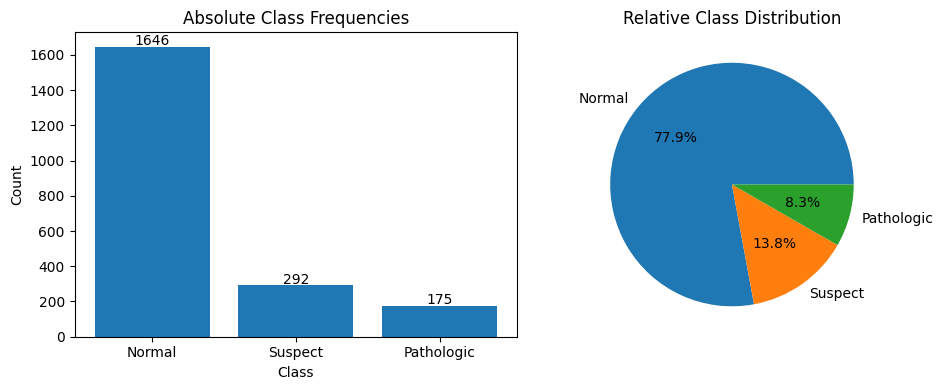

In [118]:
class_labels = {0: "Normal", 1: "Suspect", 2: "Pathologic"}
class_counts = data["NSP"].value_counts().sort_index()
class_names = [class_labels[i] for i in class_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(class_names, class_counts.values)
axes[0].set_title("Absolute Class Frequencies")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Class")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center")

axes[1].pie(
    class_counts.values,
    labels=class_names,
    autopct="%1.1f%%"
)
axes[1].set_title("Relative Class Distribution")

plt.tight_layout()
plt.show()

The dataset is clearly imbalanced: Normal recordings make up the large majority, while
Pathologic cases are the rarest. This imbalance is clinically expected but must be accounted
for in the future tasks.

## EDA Highlight 2

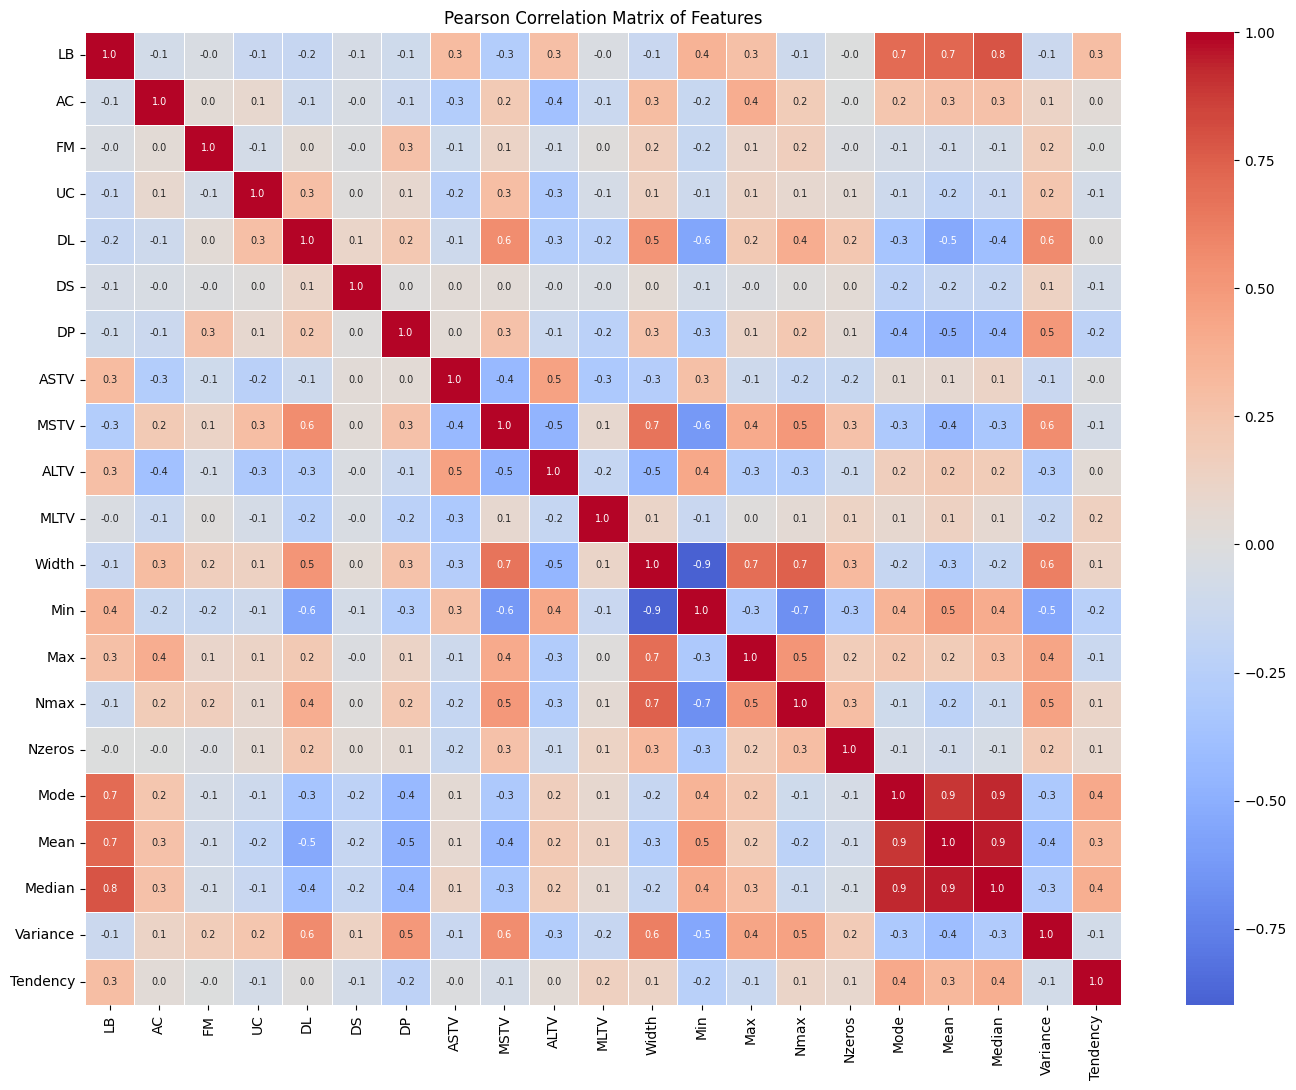

In [119]:
fig, ax = plt.subplots(figsize=(14, 11))

corr_matrix = data.drop(columns=["NSP"]).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 7}
)

ax.set_title("Pearson Correlation Matrix of Features")
plt.tight_layout()
plt.show()

This heatmap shows the corralation between the data set features. 
DS, FM, MLTV show mostly near-zero correlations with other features, meaning they  probably carry unique information.
LB, Mode, Mean, Median are highly correlated with each other that suggests they capture similar information.
It is interesting that MSTV is negatively correlated with min and positivley correlated with width, because MSTV has information about the fetal heart rate but min and width carry information about the histogram.
Width and Min show a strong negative correlation and Width and Max show strong postivie corrlation, which makes sense because the Width is calculated from the difference of max and min.
I know that this is kind of redundant information, but neural networks can handle correlated inputs features and most importantly each feature carries independent clinical meaning: a high Max value may indicate tachycardia, while a low Min value may signal bradycardia and Width reflects variability.

## EDA Highlight 3

In [120]:
corr_with_target = data.corr()["NSP"].drop("NSP").abs().sort_values(ascending=False)
corr_with_target.head(4)

DP      0.486752
ASTV    0.469671
ALTV    0.421634
AC      0.363947
Name: NSP, dtype: float64

The four features for the boxplot analysis are selected based on their Pearson
correlation (linear correlation) with NSP. 
DP (prolongued decelerations), ASTV (abnormal short-term variability), ALTV (abnormal long-term variability) and AC (accelerations) seem to be the most informative features for distinguishing between Normal, Suspect and Pathologic recordings.

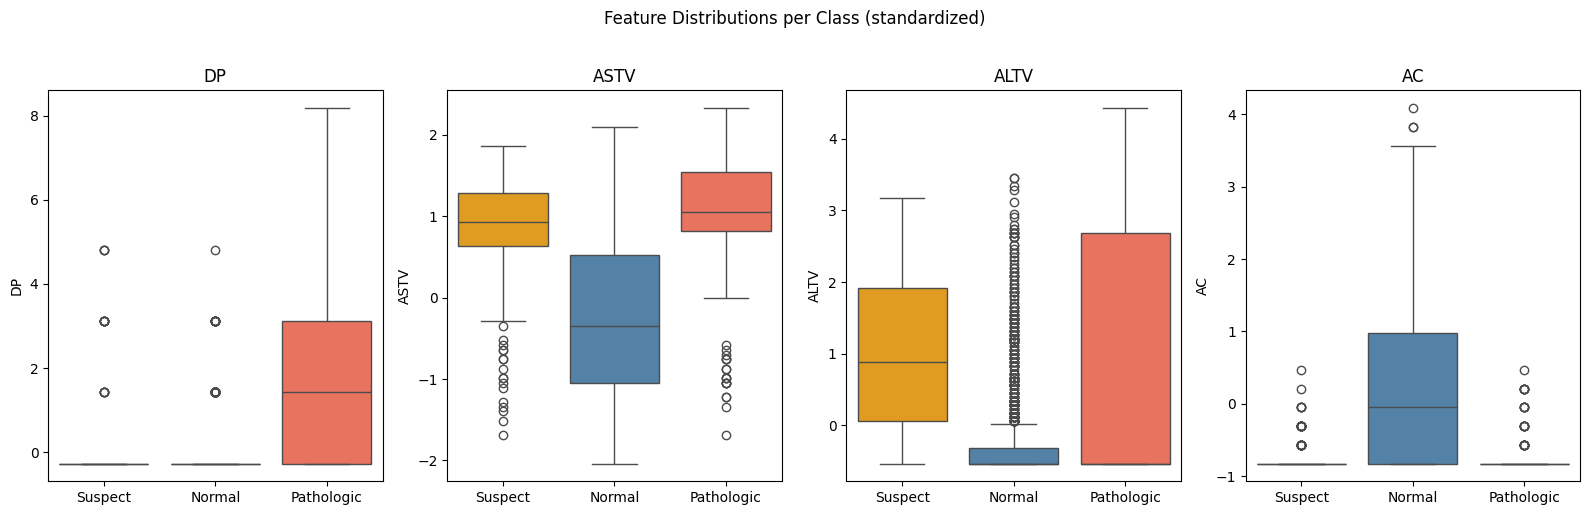

In [121]:
features_of_interest = ["DP", "ASTV", "ALTV", "AC"]
label_map = {0: "Normal", 1: "Suspect", 2: "Pathologic"}

plot_data = data.copy()
plot_data["Class"] = plot_data["NSP"].map(label_map)

fig, axes = plt.subplots(1, len(features_of_interest), figsize=(16, 5))

for i, feature in enumerate(features_of_interest):
    sns.boxplot(
        x="Class", y=feature, data=plot_data,
        palette={"Normal": "steelblue", "Suspect": "orange", "Pathologic": "tomato"},
        ax=axes[i]
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel("")

plt.suptitle("Feature Distributions per Class (standardized)", y=1.02)
plt.tight_layout()
plt.show()

DP: Normal and Suspect cases cluster near zero ( so essentially no prolonged decelerations), while Pathologic cases have a clearly elevated median and wide spread. So the presence of prolonged decelerations could stand for fetal distress.
ASTV: Both Suspect and Pathologic classes show higher ASTV, while Normal cases sit much lower.
ALTV: Normal cases are  concentrated near zero with very little spread, whereas Pathologic cases have a much higher median and extreme outliers reaching up to +4.
AC: Normal fetuses show more accelerations (higher median), while Pathologic cases have near-zero values. So accelerations could signal a healthy fetus.

# Task 5 -- Evaluation and Baseline

I use two metrics to evaluate the model:

1. Accuracy, the proportion of correctly classified instances. It is easily interpretable
   and understandable for to non-it costumors, for example doctors or clinic personal. 

2. Macro F1-Score, the unweighted mean of per-class F1-scores. Unlike accuracy, it gives
   equal weight to all three classes regardless of their frequency. This is important because of the
   class imbalance in the dataset: a model that always predicts Normal would achieve ~78%
   accuracy but a much lower Macro F1. 

   While per-class recall (sensitivity) would also be a clinically relevant metric, especially for detecting Pathologic cases, the task required exactly two metrics. I chose Accuracy as the first metric for its interpretability for non it-customers like in the clinic.

I define two simple heuristics as reference:

1. Majority Class Baseline, it always predicts the most frequent class (Normal = 0).
   This is the simplest possible strategy and represents the minimum performance any
   useful model must exceed.

2. Stratified Random Baseline, predicts a random class drawn from the empirical
   class distribution of the training set. This accounts for class imbalance while
   still being a non-learned heuristic.

Together, the two baselines define a meaningful lower bound: the Majority Class Baseline represents the absolute floor, any useful model must outperform simply predicting the dominant class. 
The Stratified Random Baseline raises that floor slightly by incorporating knowledge of the class distribution, which is the maximum information a non-trained heuristic can exploit on an imbalanced dataset. 

In [122]:
def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return {"Model": name, "Accuracy": round(acc, 4), "Macro F1": round(f1, 4)}

In [123]:
X_features = data.drop(columns=["NSP"]).values
y_labels = data["NSP"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_labels
)

In [124]:
# Baseline 1: Majority Class
majority_class = int(np.bincount(y_train).argmax())
y_pred_majority = np.full_like(y_test, fill_value=majority_class)

# Baseline 2: Stratified Random
class_probs = np.bincount(y_train) / len(y_train)
np.random.seed(42)
y_pred_random = np.random.choice(len(class_probs), size=len(y_test), p=class_probs)

# Evaluate both baselines
results_baseline = pd.DataFrame([
    evaluate(y_test, y_pred_majority, "Majority Class Baseline"),
    evaluate(y_test, y_pred_random, "Stratified Random Baseline")
])

results_baseline

,Model,Accuracy,Macro F1
0,Majority Class Baseline,0.7801,0.2922
1,Stratified Random Baseline,0.6265,0.3315


The Majority Class Baseline achieves higher accuracy due to class imbalance but a very low
Macro F1, confirming that accuracy alone is insufficient for evaluating models on this dataset.
The Stratified Random Baseline performs worse on accuracy but better on Macro F1 but all together poorly. Both metrics are performing too poor for a clinical setting.

# Task 6 -- Deep Learning Architecture

I define two neural network architectures for multiclass classification of the fetus (NSP).
Both architectures are Multilayer Perceptrons (MLPs) which work well for tabular data, but differ in
their additional components beyond linear layers and activation functions.

Both networks take 21 standardized input features and output 3 class scores (Normal, Suspect,
Pathologic). 

Both architectures share the same depth and width, which is a deliberate choice to isolate the effect of BatchNorm vs. Dropout as the single varying component. This allows for a direct comparison of the two regularization strategies.

I use CrossEntropyLoss because it is the standard loss function for multiclass classification in PyTorch. 

### Architecture 1: MLP with Batch Normalization

Batch Normalization normalizes the activations of each layer across the mini-batch, keeping
the inputs to each layer in a stable range. This accelerates training and reduces sensitivity
to weight initialization. A BatchNorm layer is applied after each linear transformation and
before the activation function.

In [125]:
class MLPBatchNorm(nn.Module):
    def __init__(self, input_size, num_classes=3):
        super(MLPBatchNorm, self).__init__()
        self.hidden1 = nn.Linear(input_size, 128)
        self.bn1     = nn.BatchNorm1d(128)
        self.hidden2 = nn.Linear(128, 64)
        self.bn2     = nn.BatchNorm1d(64)
        self.hidden3 = nn.Linear(64, 32)
        self.bn3     = nn.BatchNorm1d(32)
        self.output  = nn.Linear(32, num_classes)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.activation(self.bn1(self.hidden1(x)))
        x = self.activation(self.bn2(self.hidden2(x)))
        x = self.activation(self.bn3(self.hidden3(x)))
        return self.output(x)

model_bn = MLPBatchNorm(input_size=21)
print(model_bn)
print(f"Number of parameters: {sum(p.numel() for p in model_bn.parameters() if p.requires_grad)}")

MLPBatchNorm(
  (hidden1): Linear(in_features=21, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (hidden3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (output): Linear(in_features=32, out_features=3, bias=True)
  (activation): ReLU()
)
Number of parameters: 13699


In [126]:
summary(model_bn, input_size=(21,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 128]           2,816
       BatchNorm1d-2                  [-1, 128]             256
              ReLU-3                  [-1, 128]               0
            Linear-4                   [-1, 64]           8,256
       BatchNorm1d-5                   [-1, 64]             128
              ReLU-6                   [-1, 64]               0
            Linear-7                   [-1, 32]           2,080
       BatchNorm1d-8                   [-1, 32]              64
              ReLU-9                   [-1, 32]               0
           Linear-10                    [-1, 3]              99
Total params: 13,699
Trainable params: 13,699
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.05
Estimated Tot

### Architecture 2: MLP with Dropout

Dropout randomly deactivates a fraction of neurons during each training step, which prevents
the network from relying too heavily on individual neurons and reduces overfitting. A Dropout
layer with rate p=0.3 is applied after each activation function. Dropout is only active
during training and is automatically disabled during evaluation (model.eval()).

In [127]:
class MLPDropout(nn.Module):
    def __init__(self, input_size, num_classes=3, dropout_rate=0.3):
        super(MLPDropout, self).__init__()
        self.hidden1  = nn.Linear(input_size, 128)
        self.hidden2  = nn.Linear(128, 64)
        self.hidden3  = nn.Linear(64, 32)
        self.output   = nn.Linear(32, num_classes)
        self.activation = nn.ReLU()
        self.dropout  = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        x = self.dropout(self.activation(self.hidden1(x)))
        x = self.dropout(self.activation(self.hidden2(x)))
        x = self.dropout(self.activation(self.hidden3(x)))
        return self.output(x)

model_do = MLPDropout(input_size=21)
print(model_do)
print(f"Number of parameters: {sum(p.numel() for p in model_do.parameters() if p.requires_grad)}")

MLPDropout(
  (hidden1): Linear(in_features=21, out_features=128, bias=True)
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (hidden3): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=3, bias=True)
  (activation): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)
Number of parameters: 13251


In [128]:
summary(model_do, input_size=(21,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 128]           2,816
              ReLU-2                  [-1, 128]               0
           Dropout-3                  [-1, 128]               0
            Linear-4                   [-1, 64]           8,256
              ReLU-5                   [-1, 64]               0
           Dropout-6                   [-1, 64]               0
            Linear-7                   [-1, 32]           2,080
              ReLU-8                   [-1, 32]               0
           Dropout-9                   [-1, 32]               0
           Linear-10                    [-1, 3]              99
Total params: 13,251
Trainable params: 13,251
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.05
Estimated Tot

Both architectures have a similar number of trainable parameters (13699 and 13251) ensuring a meanigful comparison. The differences in performancen can be attributed to the regularization strategy, not the model capacity.

The key structural difference is visible in the layer order: 
MLPBatchNorm applies BatchNorm before ReLU (Linear → BatchNorm → ReLU), which normalizes the pre-activation values. 
MLPDropout applies Dropout after ReLU (Linear → ReLU → Dropout) so it randomly deactivates already-activated neurons.

# Task 7 -- Experiments

### Description of Experimental Setup

The following steps are necessary for this project:

1. **Reproducibility** – All random seeds are fixed for Python, NumPy and PyTorch to
   ensure that results can be reliably replicated.

2. **Data Split** – The preprocessed dataset is split into train (70%), validation (15%),
   and test (15%), stratified by class to preserve the class distribution across all splits.
   The validation set is used for monitoring training progress and for scheduler stepping
   (ReduceLROnPlateau). The test set is held out entirely and only used for final evaluation.

3. **DataLoader** – Training data is loaded in batches of 32 using PyTorch's DataLoader
   with shuffling enabled. This ensures that the model sees a different order of instances
   in each epoch and that weight updates are based on mini-batches rather than single instances.

4. **Loss Function** – CrossEntropyLoss is used as defined in Task 6. 

5. **Optimizer** – Adam is used as the optimizer for all experiments, with two different
   initial learning rates (0.001 and 0.01) as required by Task 7.

6. **Scheduling** – Four scheduling strategies are applied per learning rate as asked for in the task:
   - No Scheduler: constant learning rate throughout all 200 epochs
   - StepLR: learning rate is multiplied by 0.5 every 40 epochs
   - ReduceLROnPlateau: learning rate is reduced by factor 0.5 if validation loss
     does not improve for 10 consecutive epochs
   - CosineAnnealingLR: learning rate follows a cosine curve from the initial value
     down to 0 over all 200 epochs

7. **Training** – Each model is trained for 200 epochs without early stopping, as required.
   Train loss, validation loss, learning rate and validation Macro F1 are tracked each epoch.

8. **Evaluation** – After training, each model is evaluated on the held-out test set using
   Accuracy and Macro F1 as defined in Task 5.

This results in 2 architectures × 2 learning rates × 4 schedulers = **16 experiments** in total.

In [129]:
criterion = nn.CrossEntropyLoss()

schedulers_config = [
    ("NoScheduler",        None),
    ("StepLR",             "StepLR"),
    ("ReduceLROnPlateau",  "ReduceLROnPlateau"),
    ("CosineAnnealing",    "CosineAnnealing"),
]

learning_rates = [0.001, 0.01]
architectures  = ["BatchNorm", "Dropout"]

In [130]:
# Train / Validation / Test Split (70 / 15 / 15)
X_all = data.drop(columns=["NSP"]).values.astype(np.float32)
y_all = data["NSP"].values.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=SEED, shuffle=True, stratify=y_all
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, shuffle=True, stratify=y_temp
)

print(f"Train:      {len(X_train)} instances")
print(f"Validation: {len(X_val)} instances")
print(f"Test:       {len(X_test)} instances")

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_val_t   = torch.tensor(X_val)
y_val_t   = torch.tensor(y_val)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True
)

Train:      1479 instances
Validation: 317 instances
Test:       317 instances


In [131]:
def train_model(model, optimizer, scheduler, scheduler_name, criterion, epochs, train_loader, X_val, y_val):
    train_losses = []
    learning_rates_tracked = []
    val_losses   = []
    val_f1s      = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))

        model.eval()
        with torch.no_grad():
            val_out  = model(X_val)
            val_loss = criterion(val_out, y_val).item()
            _, val_pred = torch.max(val_out, dim=1)
            val_f1 = f1_score(y_val.numpy(), val_pred.numpy(), average="macro")
        val_losses.append(val_loss)
        val_f1s.append(val_f1)
        learning_rates_tracked.append(optimizer.param_groups[0]["lr"])

        if scheduler is not None:
            if scheduler_name == "ReduceLROnPlateau":
                scheduler.step(val_loss)
            else:
                scheduler.step()

    return model, train_losses, val_losses, val_f1s, learning_rates_tracked 

In [132]:
def evaluate(model, X, y, name):
    model.eval()
    with torch.no_grad():
        _, predicted = torch.max(model(X), dim=1)
    y_true = y.numpy()
    y_pred = predicted.numpy()
    return {
        "Experiment": name,
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "Macro F1":  round(f1_score(y_true, y_pred, average="macro"), 4)
    }

In [133]:
results    = []
all_curves = []

for arch in architectures:
    for lr in learning_rates:
        for sched_name, sched_key in schedulers_config:
            torch.manual_seed(SEED)

            name = f"{arch} | lr={lr} | {sched_name}"

            model = MLPBatchNorm(INPUT_SIZE) if arch == "BatchNorm" else MLPDropout(INPUT_SIZE)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)

            if sched_key is None:
                scheduler = None
            elif sched_key == "StepLR":
                scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.5)
            elif sched_key == "ReduceLROnPlateau":
                scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
            elif sched_key == "CosineAnnealing":
                scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

            model, train_losses, val_losses, val_f1s, learning_rates_tracked = train_model(
                model, optimizer, scheduler, sched_key,
                criterion, EPOCHS, train_loader, X_val_t, y_val_t
            )

            result = evaluate(model, X_test_t, y_test_t, name)
            results.append(result)
            all_curves.append({
                "name":       name,
                "train_loss": train_losses,
                "val_loss":   val_losses,
                "val_f1":     val_f1s,
                "lr":         learning_rates_tracked
            })
            print(f"Done: {name}")

results_df = pd.DataFrame(results).sort_values("Macro F1", ascending=False)


Done: BatchNorm | lr=0.001 | NoScheduler
Done: BatchNorm | lr=0.001 | StepLR
Done: BatchNorm | lr=0.001 | ReduceLROnPlateau
Done: BatchNorm | lr=0.001 | CosineAnnealing
Done: BatchNorm | lr=0.01 | NoScheduler
Done: BatchNorm | lr=0.01 | StepLR
Done: BatchNorm | lr=0.01 | ReduceLROnPlateau
Done: BatchNorm | lr=0.01 | CosineAnnealing
Done: Dropout | lr=0.001 | NoScheduler
Done: Dropout | lr=0.001 | StepLR
Done: Dropout | lr=0.001 | ReduceLROnPlateau
Done: Dropout | lr=0.001 | CosineAnnealing
Done: Dropout | lr=0.01 | NoScheduler
Done: Dropout | lr=0.01 | StepLR
Done: Dropout | lr=0.01 | ReduceLROnPlateau
Done: Dropout | lr=0.01 | CosineAnnealing


# Task 8 -- Discussion

### Overview of Results

In [134]:
results_baseline

,Model,Accuracy,Macro F1
0,Majority Class Baseline,0.7801,0.2922
1,Stratified Random Baseline,0.6265,0.3315


In [135]:
results_df

,Experiment,Accuracy,Macro F1
15,Dropout | lr=0.01 | CosineAnnealing,0.9464,0.9124
14,Dropout | lr=0.01 | ReduceLROnPlateau,0.9464,0.9072
9,Dropout | lr=0.001 | StepLR,0.9464,0.9011
7,BatchNorm | lr=0.01 | CosineAnnealing,0.9432,0.8940
4,BatchNorm | lr=0.01 | NoScheduler,0.9401,0.8939
13,Dropout | lr=0.01 | StepLR,0.9338,0.8885
11,Dropout | lr=0.001 | CosineAnnealing,0.9338,0.8852
8,Dropout | lr=0.001 | NoScheduler,0.9338,0.8819
10,Dropout | lr=0.001 | ReduceLROnPlateau,0.9432,0.8812
6,BatchNorm | lr=0.01 | ReduceLROnPlateau,0.9369,0.8803


All 16 deep learning experiments outperform both baselines on Macro F1 and Accuracy confirming that the models learned meaningful patterns.
The best configuration overall is Dropout,lr=0.01, CosineAnnealing with a Macro F1 of 0.9124 and an Accuracy of 0.9464. The worst deep learning configuration (Dropout, lr=0.01,
NoScheduler, Macro F1 = 0.8501) still outperforms both baselines by a large margin.
The overall performance range across all 16 experiments is relatively narrow (Macro F1: 0.850–0.912, Accuracy 0.9464 - 0.9180), suggesting that both architectures are generally well-suited for this dataset.

Architecture Comparison:

The Dropout architecture outperforms the BatchNorm architecture in the top 3 results.
The best BatchNorm configuration (lr=0.01, CosineAnnealing, Macro F1 = 0.8940, Accuracy = 0.9432) ranks
4th overall, while the top 3 spots are all held by Dropout configurations. This suggests
that Dropout's regularization effect is more beneficial for this dataset than BatchNorm's
training stabilization. That could possibly be because the dataset is relatively small with 2113 instances and because of that, overfitting is a real risk and Dropout directly addresses this by randomly deactivating neurons during training.


### Visualisations and Plots:

Plot 1: Loss curves (Train + Val) for all 16 experiments

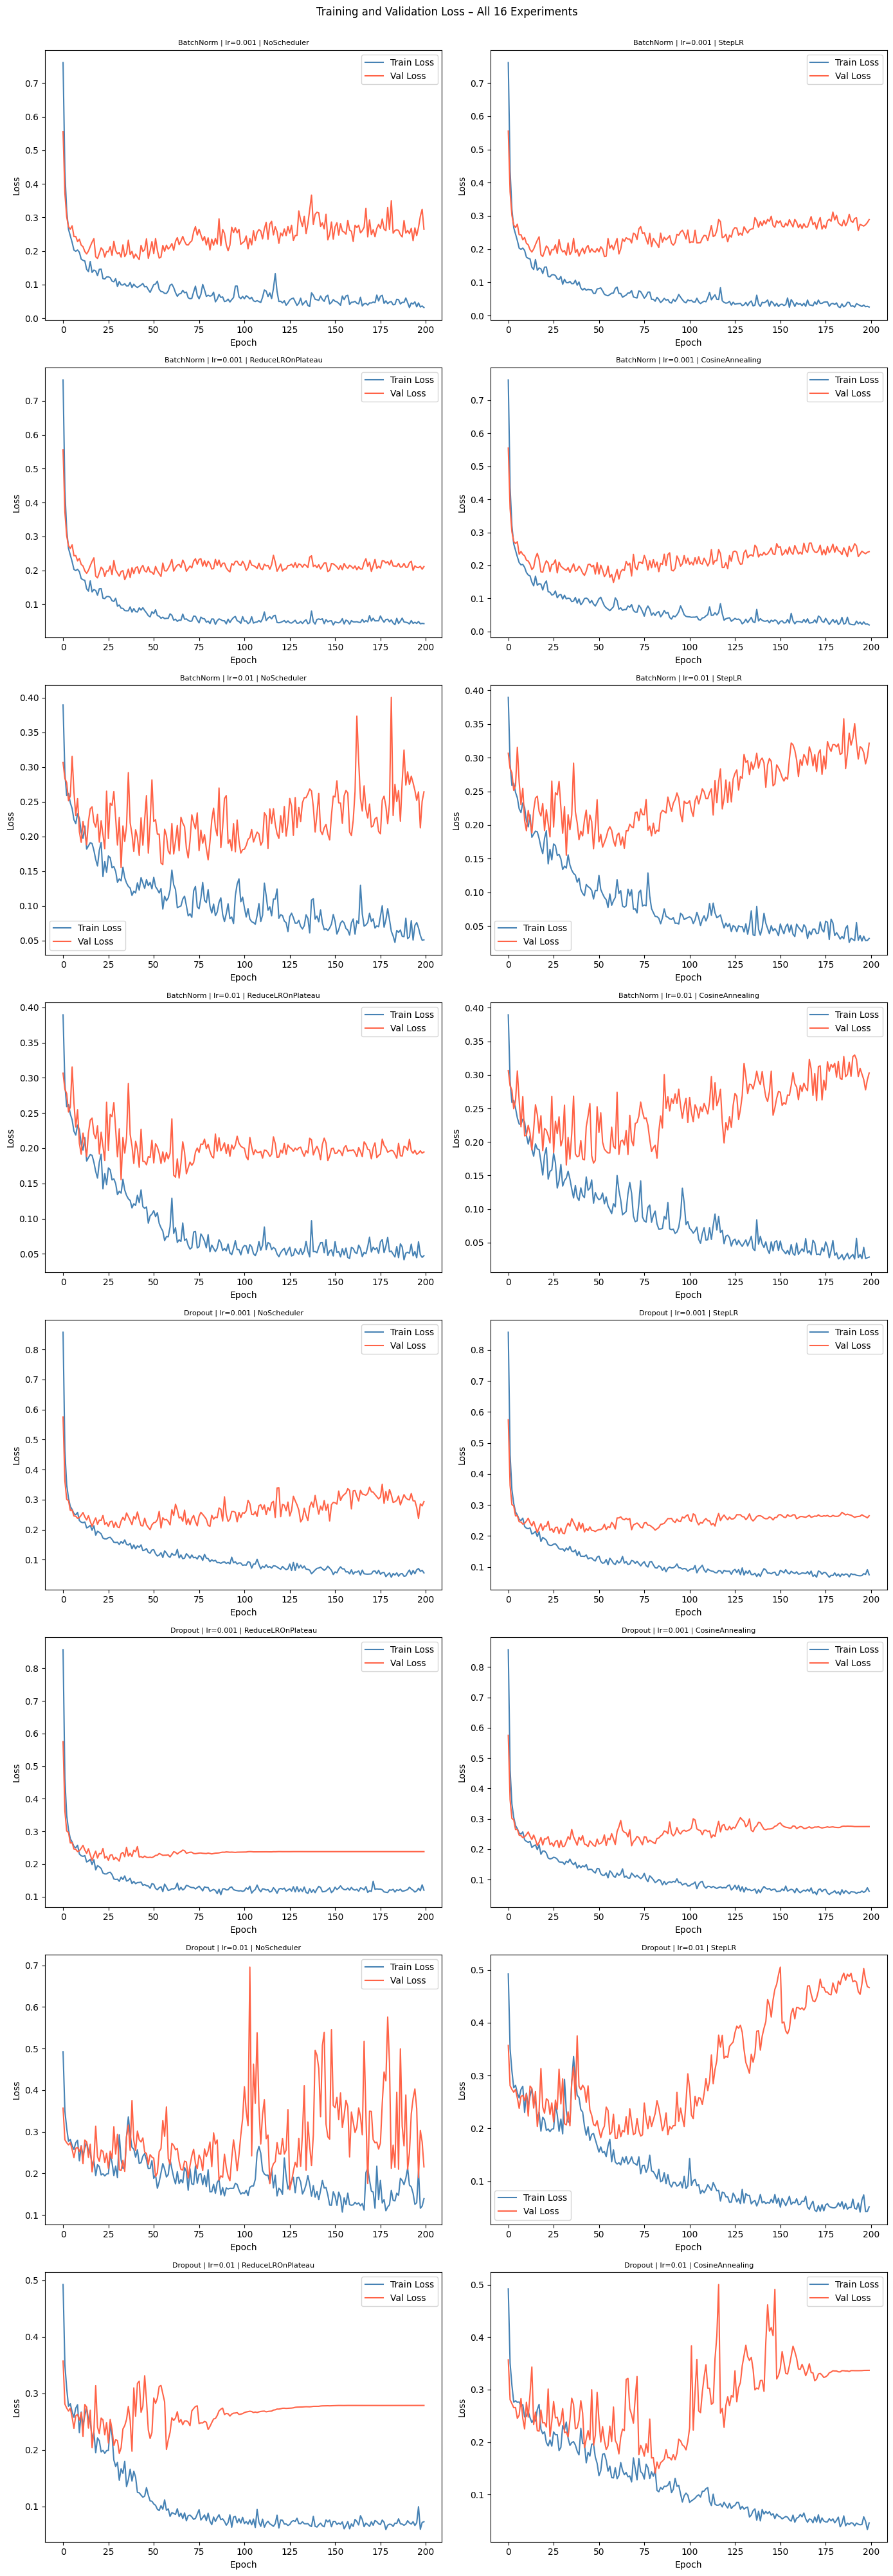

In [136]:
fig, axes = plt.subplots(8, 2, figsize=(14, 40))
axes = axes.flatten()

for i, curve in enumerate(all_curves):
    axes[i].plot(curve["train_loss"], label="Train Loss", color="steelblue")
    axes[i].plot(curve["val_loss"],   label="Val Loss",   color="tomato")
    axes[i].set_title(curve["name"], fontsize=8)
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].legend()

plt.suptitle("Training and Validation Loss – All 16 Experiments", y=1.001)
plt.tight_layout()
plt.show()

Looking at the training and validation loss curves, overfitting is visible across both architectures to varying degrees. The degree of overfitting is more strongly influenced by the scheduler and lr choice than by the architecture alone. Configurations without a scheduler or with StepLR, particularly at lr=0.01, show the largest Train/Val gaps, with validation loss plateauing or drifting upward while training loss continues to decrease. CosineAnnealing and ReduceLROnPlateau noticeably reduce this gap across both architectures with the effect being noticebly bigger at lr=0.001.
It is visible that especially DropOut at lr=0.001 and ReduceLROnPlateau has the smalles gap.
This suggests that proper learning rate scheduling needs to also be addressed when trying to reduce overfitting and not just the choice between BatchNorm and Dropout.

Plot 2: Validation Macro F1 over epochs for all 16 experiments

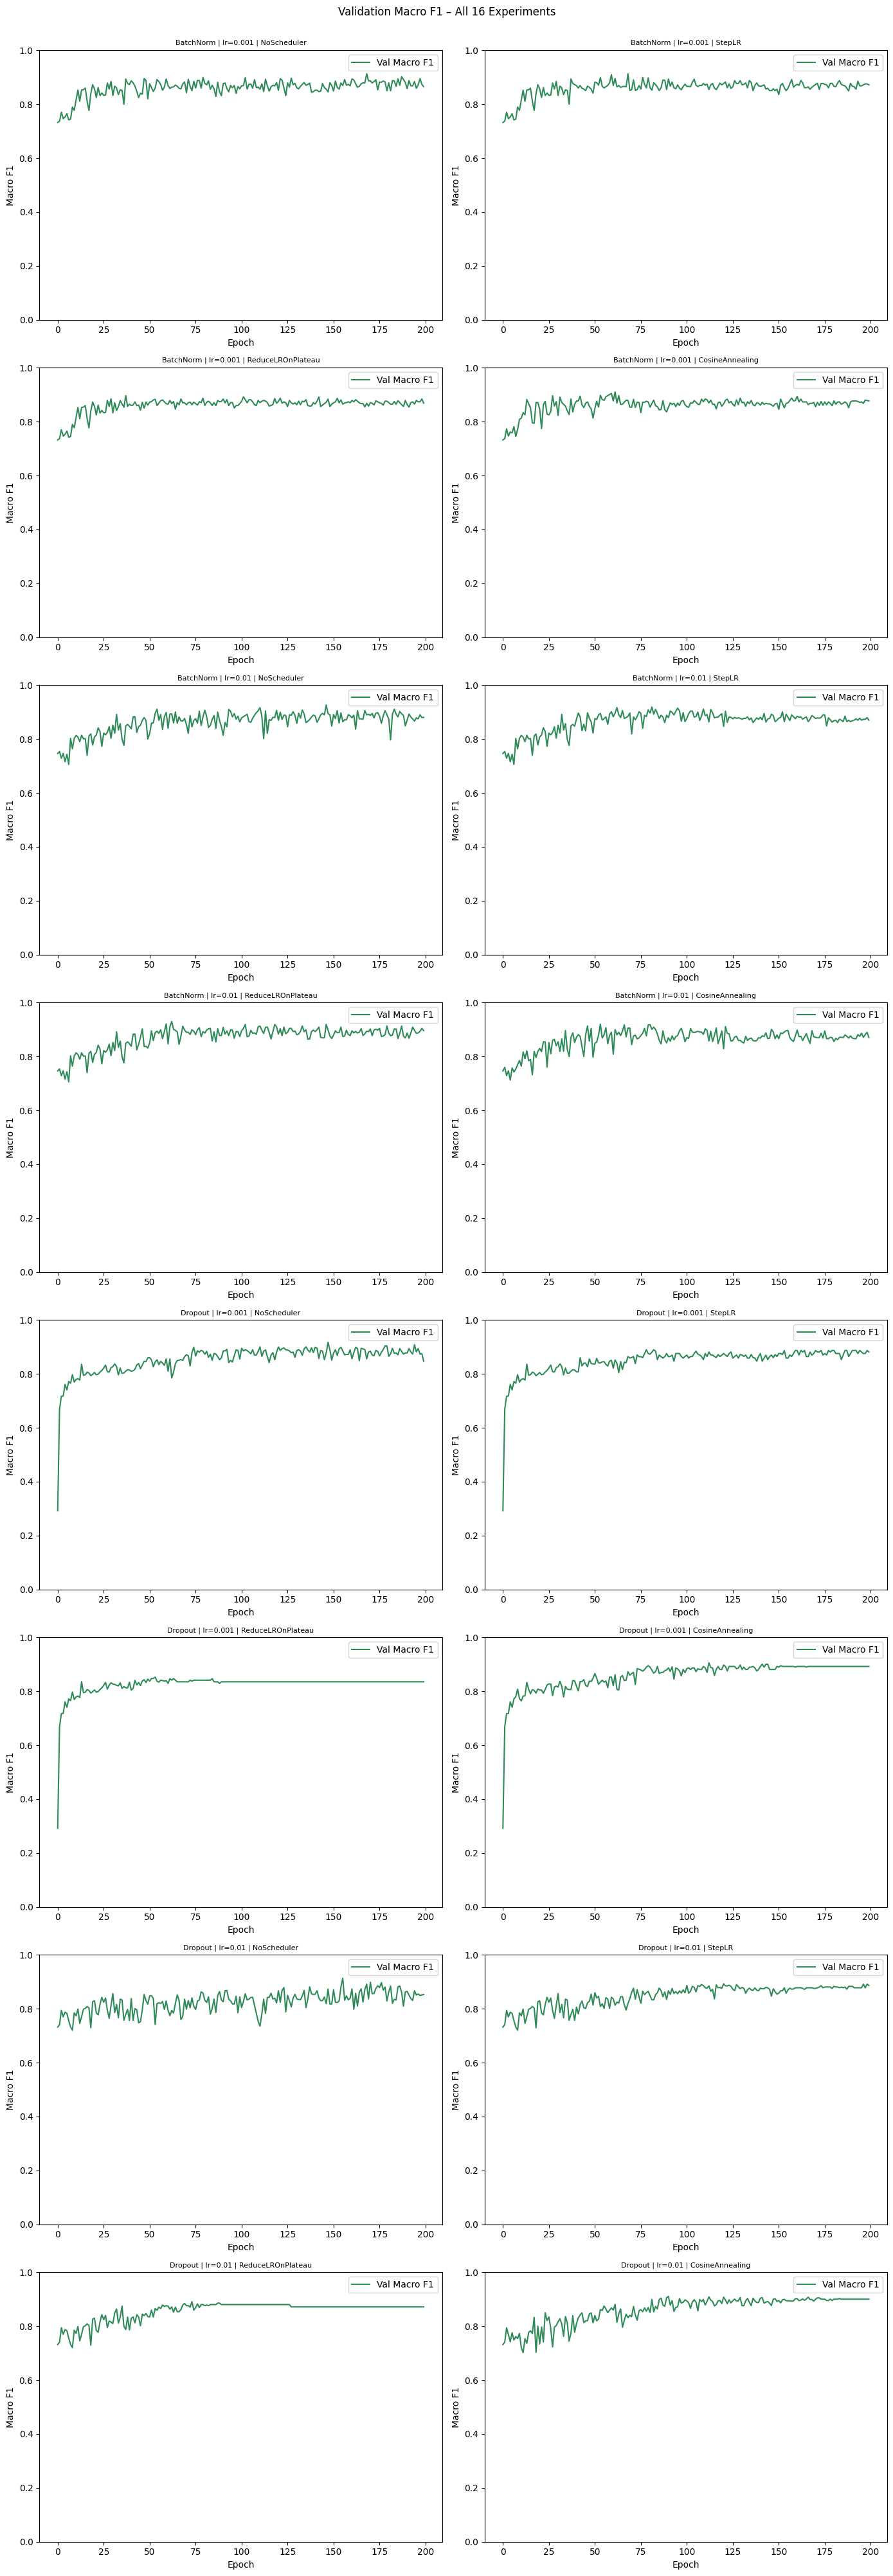

In [137]:
fig, axes = plt.subplots(8, 2, figsize=(14, 40))
axes = axes.flatten()

for i, curve in enumerate(all_curves):
    axes[i].plot(curve["val_f1"], label="Val Macro F1", color="seagreen")
    axes[i].set_title(curve["name"], fontsize=8)
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Macro F1")
    axes[i].set_ylim(0, 1)
    axes[i].legend()

plt.suptitle("Validation Macro F1 – All 16 Experiments", y=1.001)
plt.tight_layout()
plt.show()

The validation Macro F1 curves show that most configurations reach their approximate final performance level within the first 25–50 epochs, after which the curves fluctuate around a stable mean rather than showing continued improvement. This noise is expected given the relatively small validation set of 317 instances — small fluctuations in predictions have a larger impact on the metric. So 200 epochs (or even less) was a good choice, the models are not still actively improving at the end of training, meaning no meaningful performance was cut off.

The plots show again that NoScheduler perfoms the most unstable/nosier compared to their counterparts. In comparison to the former plots, the difference between lr=0.001 and lr=0.01 is less visually shown in the F1 curves than in the loss curves. 

Also BatchNorm curves seem to be a little bit more noisy than their dropout counterparts, which is somewhat counterintuitive given Dropout's stochastic nature. But also Dropout is disabled during evaluation so maybe thats the reason.

Plot 3: Learning Rate Schedules

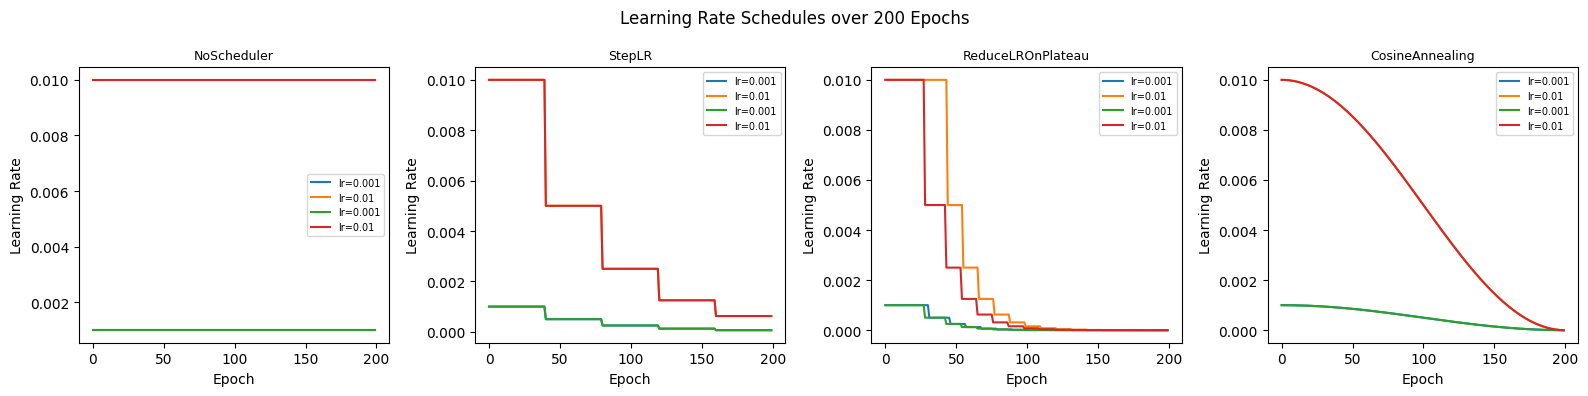

In [138]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

scheduler_names = ["NoScheduler", "StepLR", "ReduceLROnPlateau", "CosineAnnealing"]

for i, sched_name in enumerate(scheduler_names):
    # Beide Lernraten für diesen Scheduler
    for curve in [c for c in all_curves if sched_name in c["name"]]:
        lr_start = curve["lr"][0]
        axes[i].plot(curve["lr"], label=f"lr={lr_start}")
    
    axes[i].set_title(sched_name, fontsize=9)
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Learning Rate")
    axes[i].legend(fontsize=7)

plt.suptitle("Learning Rate Schedules over 200 Epochs")
plt.tight_layout()
plt.show()

The learning rate plots show the four scheduling strategies across both initial learning rates. NoScheduler keeps the rate completely constant throughout all 200 epochs, which means the optimizer never adjusts its step size regardless of training progress. StepLR produces a regular staircase pattern, halving the learning rate every 40 epochs — the drops are predictable and happen at the same epochs regardless of how the model is actually training. ReduceLROnPlateau behaves differently: the drops are irregular and happen at different points across experiments, because the scheduler only reacts when validation loss stops improving. This data-driven behavior means the learning rate adapts to the actual training dynamics rather than following a fixed schedule. CosineAnnealing produces a smooth, continuous decay from the initial value down to approximately zero at epoch 200, with no sudden jumps at any point.

These differences in scheduling behavior are reflected in the final results. CosineAnnealing's smooth decay appears to be the best match for a fixed 200-epoch training run, allowing gradual fine-tuning throughout without any abrupt disruptions. StepLR performs moderately, its fixed drops are maybe not always well-timed relative to actual training dynamics. ReduceLROnPlateau is competitive with CosineAnnealing, but its advantage of being data-driven does not translate into clearly better results here, possibly because the validation set is small enough that the plateau signal is somewhat noisy.
NoScheduler produces the worst result overall, likely because the constant learning rate prevents stable convergence in later epochs.

Conclusion:

Taken together, the results point to three main conclusions. 
First, both architectures are capable of learning the classification task well, but Dropout regularization is better suited to this relatively small dataset. 
Second, the learning rate of 0.01 is generally more effective than 0.001 regarding the Accuracy and Macro F1, while learning rate at 0.001 seems to lead to less overfitting. 
Third the choice of scheduler has a strong influence on both overfitting and final performance, more than just the choice of architecture alone. CosineAnnealing consistently produced the best results.

# Task 9 -- Conclusions and Future Work

## 1.Summary and Interpretation of results

All 16 deep learning experiments clearly outperformed both baselines on both Accuracy and Macro F1, confirming that the models learned meaningful patterns from the CTG data. The best configuration, Dropout, lr=0.01, CosineAnnealing, achieved an Accuracy of 0.9464 and a Macro F1 of 0.9124. Even the worst deep learning result, Dropout, lr=0.01, NoScheduler with Accuracy 0.9180 and Macro F1 0.8501, still beats both baselines by a large margin.

The Dropout architecture performed better overall, holding the top 3 spots in both Accuracy and Macro F1. The scheduler choice turned out to matter more than expected, CosineAnnealing and ReduceLROnPlateau produced better Accuracy and Macro F1 than NoScheduler or StepLR. Regarding overfitting CosineAnnealing and ReduceLROnPlateau with lr=0.001 seemed to achive best results.

## 2.Recommended course of action

Based on the results, I would recommend the hospital to move forward with the Dropout, lr=0.01 and CosineAnnealing model as a pre-classification support tool. With an Accuracy of 0.9464 and a Macro F1 of 0.9124, it performs well enough to meaningfully reduce the workload for doctors by automatically filtering and prioritizing incoming CTG recordings.

That said, the model should only ever support clinical decisions, not replace them. Since missing a Pathologic case is clinically far more dangerous than a false alarm, it would make sense to evaluate whether lowering the decision threshold for the Pathologic class improves recall for that class, even if it slightly reduces overall Accuracy. A controlled pilot study on more CTG data would be the right next step before any actual deployment.

## 3.Reflection of limitations and possible pitfalls

The most important limitation is the class imbalance. Even though the overall Accuracy is high at around 0.94, this number is inflated by the dominance of the Normal cases (around 78%). The Macro F1 is a better indicator of real performance across all three classes, but even that does not tell us how well the model specifically handles the 176 Pathologic cases. Per-class recall for Pathologic should be looked at explicitly before drawing conclusions about clinical usefulness.

Another limitation is that the data is from around the year 2000. Medical equipment and recording standards have changed since then, so the model's performance might not transfer directly to modern CTG devices. Finally, all results come from a single fixed train/test split so the reported Accuracy and Macro F1 numbers carry some variance that would only become visible across multiple splits, so they should be seen as estimates rather than definitive values.

## 4.Three Ideas for future work

1st idea: a class-weighted CrossEntropyLoss: Since Pathologic cases make up only around 8% of the data, the model likely sees far fewer examples of them during training. Assigning a higher loss penalty to misclassified Pathologic instances proportional to their inverse frequency would push the model to take these cases more seriously, directly addressing the class imbalance without changing the architecture. This would likely improve both per-class recall and Macro F1 while having a smaller effect on overall Accuracy.
2nd idead: Replace Macro F1 with a recall-weighted metric as the primary evaluation criterion: As discussed in Task 8, Macro F1 weights all three classes equally. For this specific clinical project, missing a Pathologic case is far more dangerous than a false alarm on a Normal case. Using a metric like weighted recall, where Pathologic recall counts more heavily give a more clinically honest picture of model performance. This would also change how the best configuration is selected: a model with slightly lower overall Accuracy but higher Pathologic recall might actually be the better clinical choice.
3rd idea: Feature selection based on findings in EDA. The EDA in Task 4 showed that DP, ASTV, ALTV and AC have the highest correlation with the target, while features like DS and FM have near-zero correlation with everything. Training the model on a reduced feature set and keeping only the most informative features could reduce noise in the input and potentially improve the generalization, especially for the minority classes. 

Other possibility would be to increase the training data by synthetic data to have more pathological cases, this would work well because all features are already continous and standardized. 

## 5. Critical discussion of the employed methodology

Positive is to mention, that fixing all random seeds across Python, NumPy and PyTorch ensures full reproducibility. The stratified 70/15/15 split preserves the class distribution across train, validation and test sets, which is important given the imbalance between Normal, Suspect and Pathologic cases.
TAlso tracking the train loss, validation loss, learning rate and validation Macro F1 across all 200 epochs gives a more detailed picture of the training more than just the final numbers.
I just used a simple train test split, a k-fold cross-validation would give more reliable estimates, especially because of the smaller dataset.
The two architectures — MLPBatchNorm and MLPDropout — share the exact same layer structure (128→64→32→3) and only differ in one component. While this was a deliberate choice to compare the effect of the regularization type, it means the experiment does not explore if a fundamentally different architecture could perform better.
Hyperparameters were based on defaults without any validation, which leaves open the question of whether a different configuration could have performed better. The task description explicitly excludes this but in a real project it would be an important step.
It is also worth noting that Macro F1 weights all classes equally, which is a reasonable choice for imbalanced data but still not fully aligned with clinical priorities. A metric that specifically rewards recall for the Pathologic class would have been more meaningful for this project and would have changed how some of the results in Task 8 are interpreted.

## 6. Critical discussion of original pitched task

The pitch proposed an automatic pre-classification system for CTG findings. The results show that this goal is genuinely achievable, the models reach Accuracy above 0.94 and Macro F1 above 0.91, which is strong enough to be useful in a real clinical support context.

Looking back though, the pitch framed the problem too broadly. Saying "classify CTG recordings into three classes" sounds reasonable, but the actual clinical value comes specifically from catching Suspect and Pathologic cases reliably. In hindsight, the pitch should have been more specific: framing the goal around maximizing recall for non-Normal cases and defining that as the primary success criterion from the start. This would have led to earlier decisions around class-weighting as core methodology rather than afterthoughts. The goals were realistic, but a more precise problem definition would have made the whole project more clinically focused.